<a href="https://www.kaggle.com/code/ibrahimnibrahim/white-blood-cells-98-test-a-dataset-accuracy?scriptVersionId=237492200" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Import the libraries:
* Tensorflow
* Numpy
* Seaborn
* Matplotlib
* Sklearn : for evaluates

In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix


2025-05-03 02:54:52.170177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746240892.331670      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746240892.378452      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Train And Test preparing

In [2]:
TRAIN_FOLDER='/kaggle/input/white-blood-cells-dataset/Train'
TEST_A_FOLDER='/kaggle/input/white-blood-cells-dataset/Test-A'

## Change images folders to data sets

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_FOLDER,            
    label_mode='categorical',        
    image_size=(224, 224),            
    batch_size=64                    
)

test_a_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=TEST_A_FOLDER,              
    label_mode='categorical',        
    image_size=(224, 224),            
    batch_size=64                    
)

class_names=train_dataset.class_names

Found 10175 files belonging to 5 classes.


I0000 00:00:1746240927.777251      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4339 files belonging to 5 classes.


## Cache and prefetch the Train and test Datasets

In [4]:
train_dataset=train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE).shuffle(buffer_size=1000)
test_a_dataset=test_a_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#  EfficientNetB3 model with augmentation 

In [5]:
base_model = EfficientNetB3(
    weights='imagenet',  
    input_shape=(224, 224, 3),
    include_top=False    
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])


inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)        
x = base_model(x, training=False)        
x = layers.GlobalAveragePooling2D()(x)    
x = layers.Dense(512, activation='relu')(x)  
x = layers.Dense(5, activation='softmax')(x) 

final_model = models.Model(inputs=inputs, outputs=x)

final_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb3 (Functional)          │ (None, 7, 7, 1536)          │      10,783,535 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1536)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         786,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,573,044 (44.15 MB)

 Trainable params: 11,485,741 (43.81 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [6]:
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Create Callback from custom training

In [7]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5,  
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=3, 
    min_lr=1e-7
)


class StopOnValAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target=0.985):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is not None and val_acc >= self.target:
            print(f"\nReached {val_acc:.2%} val_accuracy — stopping training.")
            self.model.stop_training = True

## Start training 

In [8]:
history = final_model.fit(
    train_dataset,
    validation_data=test_a_dataset,
    epochs=100,
    callbacks=[early_stopping, reduce_lr,StopOnValAccuracy(target=0.980)]
)

Epoch 1/100


E0000 00:00:1746241027.253191      19 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1746241063.420598      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


159/159 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8870 - loss: 0.3313 - val_accuracy: 0.9078 - val_loss: 0.2381 - learning_rate: 0.0010
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 149s 935ms/step - accuracy: 0.9728 - loss: 0.0839 - val_accuracy: 0.9728 - val_loss: 0.0927 - learning_rate: 0.0010
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 148s 933ms/step - accuracy: 0.9768 - loss: 0.0747 - val_accuracy: 0.9562 - val_loss: 0.1597 - learning_rate: 0.0010
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 148s 931ms/step - accuracy: 0.9856 - loss: 0.0494 - val_accuracy: 0.9753 - val_loss: 0.0779 - learning_rate: 0.0010
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.9879 - loss: 0.0389
Reached 98.50% val_accuracy — stopping training.
159/159 ━━━━━━━━━━━━━━━━━━━━ 149s 937ms/step - accuracy: 0.9879 - loss: 0.0389 - val_accuracy: 0.9850 - val_loss: 0.0478 - learning_rate: 0.0010


# model Evaluate

In [9]:
final_model.evaluate(test_a_dataset)

68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9865 - loss: 0.0432


[0.047822583466768265, 0.9850195646286011]

## Classification Report

In [10]:
y_true = []
y_pred_probs = []

for images, labels in test_a_dataset:
    y_true.extend(labels.numpy())
    y_pred_probs.extend(final_model.predict(images, verbose=0))

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Check if labels are one-hot encoded
if len(y_true.shape) > 1 and y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)

y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

    Basophil     0.8725    1.0000    0.9319        89
  Eosinophil     0.9872    0.9565    0.9716       322
  Lymphocyte     0.9902    0.9816    0.9859      1034
    Monocyte     0.9264    0.9145    0.9204       234
  Neutrophil     0.9921    0.9955    0.9938      2660

    accuracy                         0.9850      4339
   macro avg     0.9537    0.9696    0.9607      4339
weighted avg     0.9853    0.9850    0.9851      4339



## Confusion Matrix

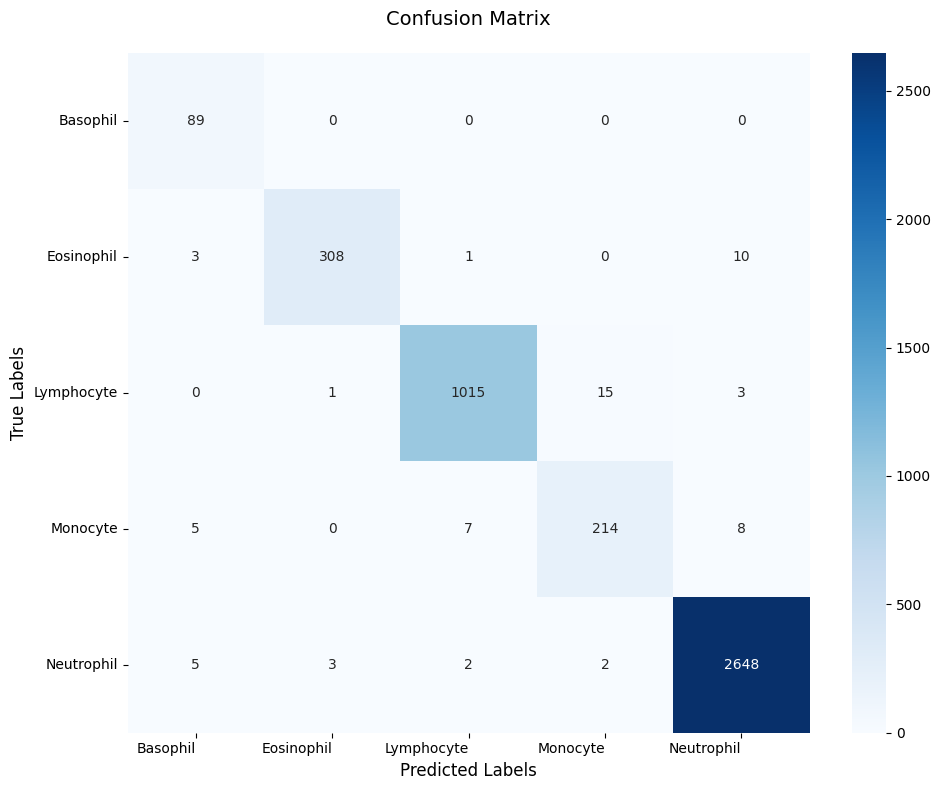

In [11]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Plots a beautiful confusion matrix with annotations
    
    Args:
        y_true: Array of true labels
        y_pred: Array of predicted labels
        class_names: List of class names
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    
    # Add labels and title
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, pad=20)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=0, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()

# Usage with your TensorFlow dataset
# 1. Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_a_dataset:
    # Get true labels (convert from one-hot if needed)
    if len(labels.shape) > 1:  # If one-hot encoded
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    else:
        y_true.extend(labels.numpy())
    
    # Get predictions
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Get class names
# class_names = test_dataset.class_names

# 3. Plot confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names)

## Normalized confusion matrix

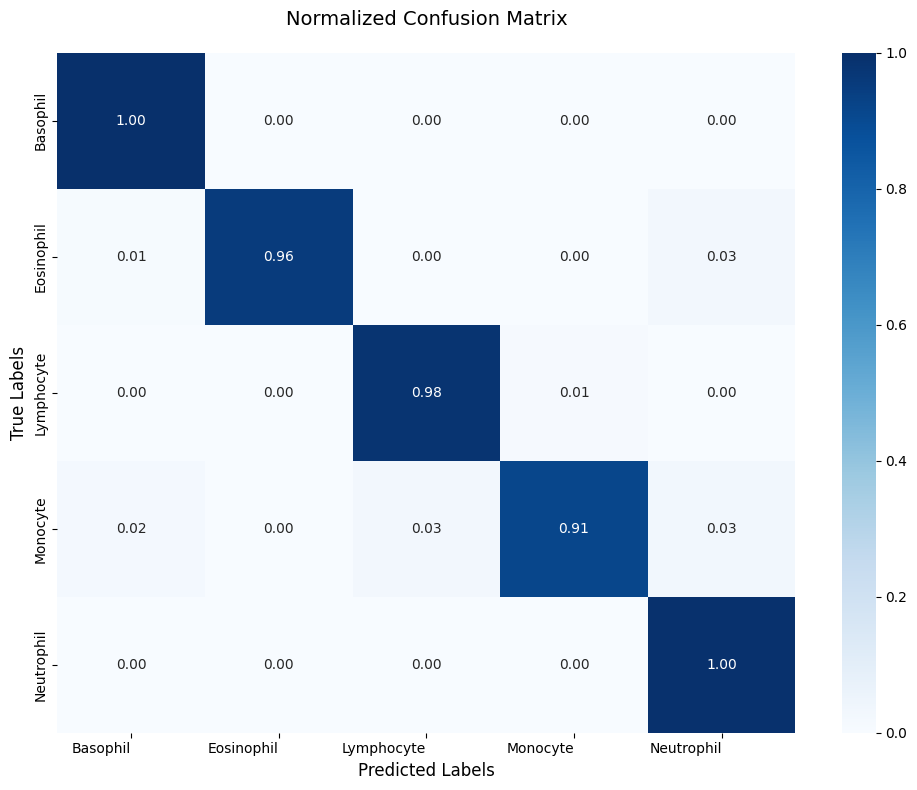

In [12]:
def plot_normalized_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names,
                vmin=0, vmax=1)
    
    plt.xlabel('Predicted Labels', fontsize=12)
    plt.ylabel('True Labels', fontsize=12)
    plt.title('Normalized Confusion Matrix', fontsize=14, pad=20)
    plt.xticks(rotation=0, ha='right')
    plt.tight_layout()
    plt.show()

plot_normalized_confusion_matrix(y_true, y_pred, class_names)

# PLOT SOME PREDICTIONS

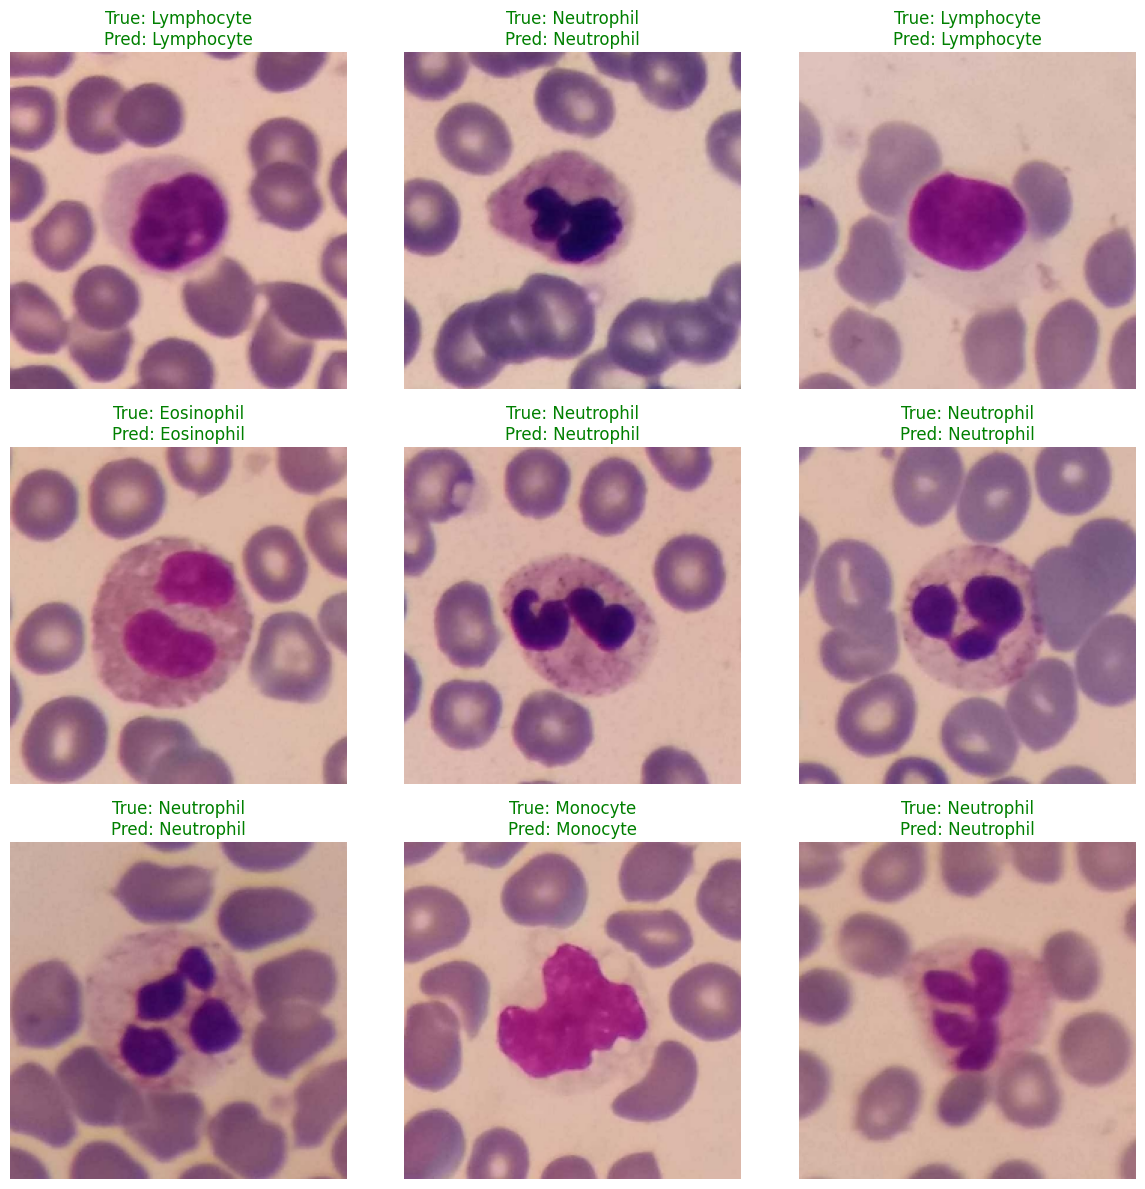

In [13]:
def plot_predictions(model, dataset, class_names, num_images=9):
    """
    Plots images with their true and predicted labels
    
    Args:
        model: Trained Keras model
        dataset: TensorFlow dataset (batched)
        class_names: List of class names
        num_images: Number of images to display (default 9)
    """
    plt.figure(figsize=(12, 12))
    
    # Take one batch from the dataset
    for images, labels in dataset.take(1):
        # Make predictions
        preds = final_model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        
        # Convert one-hot labels if needed
        if len(labels.shape) > 1:
            true_classes = np.argmax(labels.numpy(), axis=1)
        else:
            true_classes = labels.numpy()
        
        # Plot images
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 3, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            # Set title with color coding
            true_label = class_names[true_classes[i]]
            pred_label = class_names[pred_classes[i]]
            
            color = 'green' if true_label == pred_label else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Usage
plot_predictions(final_model, test_a_dataset, class_names)

In [14]:
final_model.save('White Bolld Cells.keras')